# 02 — Baseline Model: MFCC + SVM / Random Forest

Train and evaluate baseline classifiers on UrbanSound8K using MFCC features.

**Pipeline**: Audio clips → MFCC extraction (40 coefficients + deltas) → StandardScaler → SVM or Random Forest → 10-class classification.

**Evaluation**: Using UrbanSound8K's predefined fold 10 as test set (folds 1-8 train, fold 9 val).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sys
sys.path.insert(0, '/content/drive/MyDrive/NYC-cafe-study-friendliness')

!pip install librosa soundfile scikit-learn -q

Mounted at /content/drive


In [2]:
import sys
import os
from pathlib import Path


PROJECT_ROOT = '/content/drive/MyDrive/NYC-cafe-study-friendliness'
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

from src.dataset import get_fold_data, get_default_split, CLASS_NAMES
from src.audio_features import extract_mfcc_batch
from src.baseline_model import train_baseline, evaluate_baseline, save_model

%matplotlib inline

DATA_DIR = os.path.join(PROJECT_ROOT, "data", "UrbanSound8K")
SR = 22050
N_MFCC = 40

## 1. Load Data and Extract Features

In [7]:

!cp -r "/content/drive/MyDrive/NYC-cafe-study-friendliness/data/UrbanSound8K" "/content/UrbanSound8K"

DATA_DIR = "/content/UrbanSound8K"

split = get_default_split()
print(f"Train folds: {split['train']}, Val folds: {split['val']}, Test folds: {split['test']}")

# Load audio data
print("\nLoading training data...")
train_audios, y_train, train_meta = get_fold_data(DATA_DIR, split["train"], sr=SR)
print(f"  {len(train_audios)} training clips")

print("Loading validation data...")
val_audios, y_val, val_meta = get_fold_data(DATA_DIR, split["val"], sr=SR)
print(f"  {len(val_audios)} validation clips")

print("Loading test data...")
test_audios, y_test, test_meta = get_fold_data(DATA_DIR, split["test"], sr=SR)
print(f"  {len(test_audios)} test clips")

Train folds: [1, 2, 3, 4, 5, 6, 7, 8], Val folds: [9], Test folds: [10]

Loading training data...
  7079 training clips
Loading validation data...
  816 validation clips
Loading test data...
  837 test clips


In [8]:
# Extract MFCC features
print("Extracting MFCC features...")
X_train = extract_mfcc_batch(train_audios, sr=SR, n_mfcc=N_MFCC)
X_val = extract_mfcc_batch(val_audios, sr=SR, n_mfcc=N_MFCC)
X_test = extract_mfcc_batch(test_audios, sr=SR, n_mfcc=N_MFCC)

print(f"Feature dimensions: {X_train.shape[1]} (n_mfcc={N_MFCC} x 6 stats)")
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Extracting MFCC features...
Feature dimensions: 240 (n_mfcc=40 x 6 stats)
Train: (7079, 240), Val: (816, 240), Test: (837, 240)


## 2. Train Random Forest Baseline

In [9]:
# Train Random Forest
print("Training Random Forest...")
rf_model = train_baseline(X_train, y_train, model_type="rf")

# Evaluate on validation set
print("\n--- Validation Results ---")
val_results_rf = evaluate_baseline(rf_model, X_val, y_val)
print(f"Validation Accuracy: {val_results_rf['accuracy']:.4f}")
print(val_results_rf["report"])

Training Random Forest...

--- Validation Results ---
Validation Accuracy: 0.6850
                  precision    recall  f1-score   support

 air_conditioner       0.66      0.19      0.29       100
        car_horn       0.96      0.81      0.88        32
children_playing       0.74      0.80      0.77       100
        dog_bark       0.55      0.66      0.60       100
        drilling       0.54      0.50      0.52       100
   engine_idling       0.81      0.89      0.84        89
        gun_shot       0.66      0.61      0.63        31
      jackhammer       0.49      0.65      0.55        82
           siren       0.94      0.91      0.93        82
    street_music       0.74      0.92      0.82       100

        accuracy                           0.69       816
       macro avg       0.71      0.69      0.68       816
    weighted avg       0.69      0.69      0.67       816



In [10]:
# Evaluate on test set
print("--- Test Results ---")
test_results_rf = evaluate_baseline(rf_model, X_test, y_test)
print(f"Test Accuracy: {test_results_rf['accuracy']:.4f}")
print(test_results_rf["report"])

--- Test Results ---
Test Accuracy: 0.7264
                  precision    recall  f1-score   support

 air_conditioner       0.81      0.77      0.79       100
        car_horn       0.83      0.45      0.59        33
children_playing       0.56      0.80      0.66       100
        dog_bark       0.78      0.75      0.77       100
        drilling       0.67      0.66      0.66       100
   engine_idling       0.87      0.76      0.81        93
        gun_shot       0.72      0.81      0.76        32
      jackhammer       0.79      0.81      0.80        96
           siren       0.66      0.51      0.57        83
    street_music       0.74      0.78      0.76       100

        accuracy                           0.73       837
       macro avg       0.74      0.71      0.72       837
    weighted avg       0.74      0.73      0.73       837



## 3. Train SVM Baseline

In [11]:
# Train SVM
print("Training SVM (this may take a few minutes)...")
svm_model = train_baseline(X_train, y_train, model_type="svm")

# Evaluate on test set
print("\n--- Test Results ---")
test_results_svm = evaluate_baseline(svm_model, X_test, y_test)
print(f"Test Accuracy: {test_results_svm['accuracy']:.4f}")
print(test_results_svm["report"])

Training SVM (this may take a few minutes)...

--- Test Results ---
Test Accuracy: 0.7300
                  precision    recall  f1-score   support

 air_conditioner       0.87      0.74      0.80       100
        car_horn       0.93      0.85      0.89        33
children_playing       0.55      0.82      0.66       100
        dog_bark       0.74      0.77      0.75       100
        drilling       0.65      0.71      0.68       100
   engine_idling       0.88      0.80      0.84        93
        gun_shot       0.96      0.81      0.88        32
      jackhammer       0.73      0.58      0.65        96
           siren       0.63      0.57      0.59        83
    street_music       0.80      0.76      0.78       100

        accuracy                           0.73       837
       macro avg       0.77      0.74      0.75       837
    weighted avg       0.75      0.73      0.73       837



## 4. Confusion Matrices

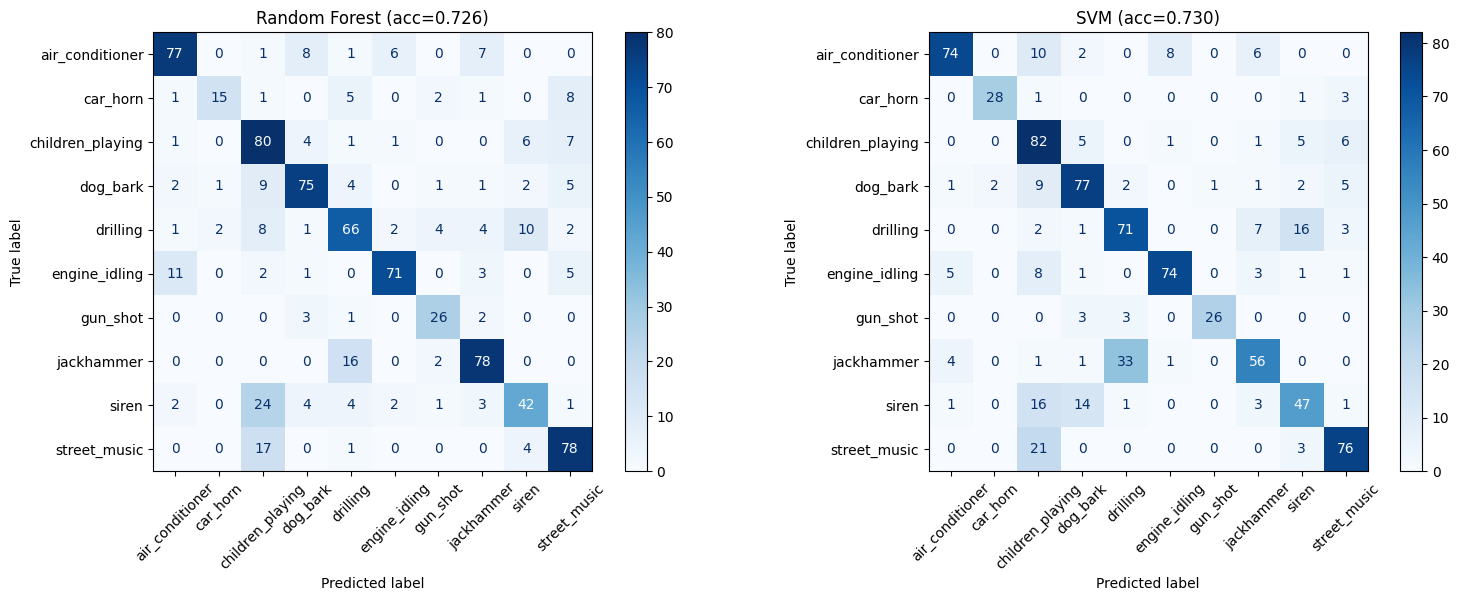

In [12]:
target_names = [CLASS_NAMES[i] for i in range(10)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, test_results_rf["predictions"],
    display_labels=target_names, ax=axes[0],
    xticks_rotation=45, cmap="Blues"
)
axes[0].set_title(f"Random Forest (acc={test_results_rf['accuracy']:.3f})")

# SVM confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, test_results_svm["predictions"],
    display_labels=target_names, ax=axes[1],
    xticks_rotation=45, cmap="Blues"
)
axes[1].set_title(f"SVM (acc={test_results_svm['accuracy']:.3f})")

plt.tight_layout()
plt.show()

## 5. Compare Models and Save Best

In [13]:
# Summary
print("=" * 50)
print("Baseline Model Comparison (Test Set)")
print("=" * 50)
print(f"Random Forest: {test_results_rf['accuracy']:.4f}")
print(f"SVM (RBF):     {test_results_svm['accuracy']:.4f}")

# Save the better model
best_name = "rf" if test_results_rf["accuracy"] >= test_results_svm["accuracy"] else "svm"
best_model = rf_model if best_name == "rf" else svm_model
best_acc = max(test_results_rf["accuracy"], test_results_svm["accuracy"])

models_dir = os.path.join(PROJECT_ROOT, "models")
os.makedirs(models_dir, exist_ok=True)
save_model(best_model, os.path.join(models_dir, f"baseline_{best_name}.joblib"))
print(f"\nBest model ({best_name.upper()}, acc={best_acc:.4f}) saved.")

Baseline Model Comparison (Test Set)
Random Forest: 0.7264
SVM (RBF):     0.7300
Model saved to /content/drive/MyDrive/NYC-cafe-study-friendliness/models/baseline_svm.joblib

Best model (SVM, acc=0.7300) saved.


In [14]:
## 6. Full 10-fold Cross-Validation
from src.baseline_model import run_kfold_cv

print("=== Random Forest 10-fold CV ===")
rf_results = run_kfold_cv(DATA_DIR, model_type="rf")

print("\n=== SVM 10-fold CV ===")
svm_results = run_kfold_cv(DATA_DIR, model_type="svm")


=== Random Forest 10-fold CV ===
Fold  1: accuracy = 0.6552
Fold  2: accuracy = 0.6453
Fold  3: accuracy = 0.6032
Fold  4: accuracy = 0.6889
Fold  5: accuracy = 0.7276
Fold  6: accuracy = 0.6343
Fold  7: accuracy = 0.6480
Fold  8: accuracy = 0.6774
Fold  9: accuracy = 0.7083
Fold 10: accuracy = 0.7479

10-Fold CV: 0.6736 +/- 0.0449

=== SVM 10-fold CV ===
Fold  1: accuracy = 0.6300
Fold  2: accuracy = 0.6734
Fold  3: accuracy = 0.6097
Fold  4: accuracy = 0.7020
Fold  5: accuracy = 0.7682
Fold  6: accuracy = 0.6245
Fold  7: accuracy = 0.7255
Fold  8: accuracy = 0.6340
Fold  9: accuracy = 0.7255
Fold 10: accuracy = 0.7312

10-Fold CV: 0.6824 +/- 0.0554


## Next Steps

- **Full 10-fold CV**: Run `src/baseline_model.py::run_kfold_cv()` for proper evaluation
- **CNN model**: Train a CNN on mel-spectrograms (future milestone)
- **Cafe recordings**: Apply trained model to field recordings from NYC cafes
- **Scoring**: Combine predictions with spatial features for study-friendliness scores